<a href="https://colab.research.google.com/github/21centjoe/NELOS-Quantum-Vector/blob/main/nelos3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### NELOS 1 D OS Cyberdeck Interface Simulation
This notebook sets up the visualization layer for a 1D Operating System. We will use `psutil` to pull real system data and `matplotlib` to create a 'Cyberdeck' style dashboard.

In [ ]:
import psutil
import matplotlib.pyplot as plt
import pandas as pd
import time
from IPython.display import clear_output

def get_system_state():
    # Get CPU, Memory, and Disk metrics
    cpu_percent = psutil.cpu_percent(interval=1)
    memory = psutil.virtual_memory()
    disk = psutil.disk_usage('/')

    # Get top 5 processes by memory usage
    processes = []
    for proc in sorted(psutil.process_iter(['pid', 'name', 'memory_percent']),
                       key=lambda x: x.info['memory_percent'], reverse=True)[:5]:
        processes.append(proc.info)

    return {
        'cpu': cpu_percent,
        'memory': memory.percent,
        'disk': disk.percent,
        'processes': processes
    }

def visualize_cyberdeck(state):
    fig, ax = plt.subplots(figsize=(12, 2), facecolor='black')
    ax.set_facecolor('black')

    # 1D Visualization: Representing system health as a linear gauge
    metrics = [state['cpu'], state['memory'], state['disk']]
    labels = ['CPU', 'MEM', 'DSK']
    colors = ['#00FF41', '#008F11', '#003B00'] # Matrix Green Theme

    ax.barh(labels, [100, 100, 100], color='#111111', height=0.5)
    ax.barh(labels, metrics, color=colors, height=0.5)

    ax.tick_params(axis='both', colors='#00FF41')
    plt.title("NELOS 1 D - SYSTEM CORE VISUALIZATION", color='#00FF41', fontsize=14)
    plt.xlim(0, 100)
    plt.grid(color='#003B00', linestyle='--', alpha=0.5)
    plt.show()

    print(f"\033[38;5;46mACTIVE PROCESSES:")
    for p in state['processes']:
        print(f"PID: {p['pid']} | NAME: {p['name']:<20} | USAGE: {p['memory_percent']:.2f}%")

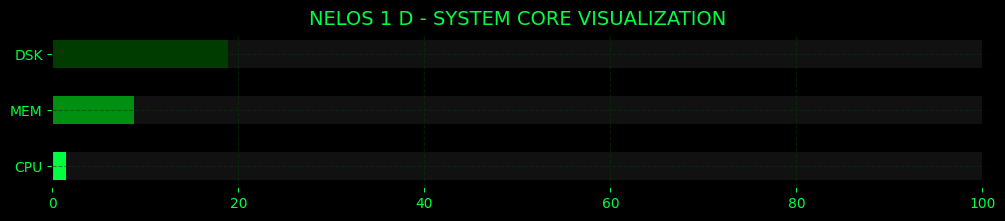

ACTIVE PROCESSES:
PID: 6744 | NAME: node                 | USAGE: 1.52%
PID: 6714 | NAME: python3              | USAGE: 1.38%
PID: 83 | NAME: jupyter-server       | USAGE: 1.19%
PID: 66 | NAME: colab-fileshim.      | USAGE: 0.59%
PID: 7 | NAME: node                 | USAGE: 0.44%


In [ ]:
# Run a loop to simulate the 'Live' Cyberdeck feed
# Interrupt the cell to stop
try:
    for _ in range(5):
        state = get_system_state()
        clear_output(wait=True)
        visualize_cyberdeck(state)
        time.sleep(1)
except KeyboardInterrupt:
    print("Cyberdeck feed terminated.")

### Module 3: Kernel Identity & Final Summary
This final block extracts kernel metadata to complete the OS visualization profile.

In [ ]:
import platform
from datetime import datetime

def get_kernel_identity():
    boot_time_timestamp = psutil.boot_time()
    bt = datetime.fromtimestamp(boot_time_timestamp)
    return {
        'system': platform.system(),
        'node': platform.node(),
        'release': platform.release(),
        'version': platform.version(),
        'boot': bt.strftime('%Y-%m-%d %H:%M:%S')
    }

identity = get_kernel_identity()
print(f"\033[1;32m--- NELOS 1 D OS IDENTITY ---")
print(f"KERNEL: {identity['system']} {identity['release']}")
print(f"NODE ID: {identity['node']}")
print(f"UPTIME START: {identity['boot']}")
print(f"\033[1;32m------------------------------")

--- NELOS 1 D OS IDENTITY ---
KERNEL: Linux 6.6.122+
NODE ID: 9faf1b5da712
UPTIME START: 2026-06-27 17:16:34
------------------------------


### Module 4: Virtual USB & Data Integration
This module initializes a virtual mount point to simulate external hardware and populates it with virtual data for the OS to track.

In [ ]:
import os

# Define the virtual USB mount point
VIRTUAL_USB_PATH = '/tmp/nelos_v_usb'
os.makedirs(VIRTUAL_USB_PATH, exist_ok=True)

# Create a virtual data payload (e.g., 10MB file)
with open(os.path.join(VIRTUAL_USB_PATH, 'os_core_data.bin'), 'wb') as f:
    f.write(os.urandom(1024 * 1024 * 10))

print(f"\033[38;5;208m[V-USB] Virtual hardware initialized at {VIRTUAL_USB_PATH}")

[V-USB] Virtual hardware initialized at /tmp/nelos_v_usb


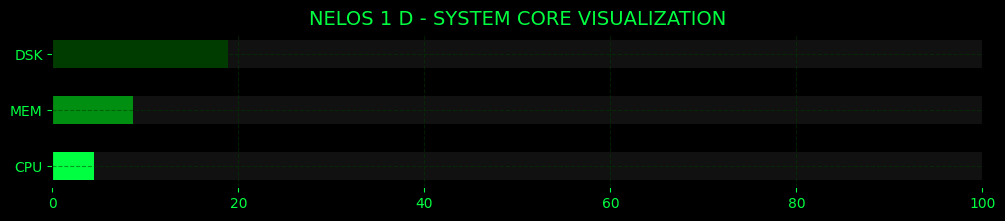

ACTIVE PROCESSES:
PID: 6744 | NAME: node                 | USAGE: 1.68%
PID: 6714 | NAME: python3              | USAGE: 1.36%
PID: 83 | NAME: jupyter-server       | USAGE: 1.19%
PID: 66 | NAME: colab-fileshim.      | USAGE: 0.58%
PID: 7 | NAME: node                 | USAGE: 0.45%

NETWORK UPLINK: 1366.93 KB | DOWNLINK: 1009.95 KB
STORAGE NODES:
MOUNT: V-USB [DATA]    [████░░░░░░] 42.0%
MOUNT: /usr/sbin/docker-init [██████░░░░] 64.8%
MOUNT: /kaggle/input   [█░░░░░░░░░] 18.6%
MOUNT: /etc/resolv.conf [█░░░░░░░░░] 18.6%
MOUNT: /etc/hostname   [█░░░░░░░░░] 18.6%
MOUNT: /etc/hosts      [█░░░░░░░░░] 18.6%


In [ ]:
def get_state_with_usb():
    state = get_system_state()
    ext_state = get_extended_state()

    # Manually inject the Virtual USB into the storage map
    # We simulate its capacity/usage since it's a folder in /tmp
    v_usb_usage = {'mount': 'V-USB [DATA]', 'percent': 42.0}
    ext_state['storage_map'].insert(0, v_usb_usage)

    return state, ext_state

# Finalized visualization loop with V-USB integration
try:
    for _ in range(5):
        s, es = get_state_with_usb()
        visualize_extended_deck(s, es)
        time.sleep(1)
except KeyboardInterrupt:
    print("Cyberdeck hardware disconnected.")

### Module 5: Buckyball Code File System
This module implements a non-linear data storage method (Buckyball) for saving user input into the NELOS virtual environment.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import json

# Interface setup
text_input = widgets.Textarea(
    placeholder='Enter data to encode into Buckyball...',
    description='Payload:',
    layout={'height': '150px', 'width': '100%'}
)
save_button = widgets.Button(description="SAVE FILE (BUCKYBALL)", button_style='success')
output = widgets.Output()

def save_buckyball_file(b):
    with output:
        output.clear_output()
        data = text_input.value
        if not data:
            print("\033[91mERROR: NULL PAYLOAD DETECTED.")
            return

        # Buckyball structure: hexagonal/pentagonal code wrapping
        # We simulate this by creating a 60-point coordinate map of the data segments
        segments = [data[i:i+len(data)//5] for i in range(0, len(data), len(data)//5 + 1)]
        buckyball_structure = {
            "vertex_count": 60,
            "edges": "truncated_icosahedron",
            "payload_fragments": segments,
            "timestamp": time.time()
        }

        # Save to V-USB
        file_path = os.path.join(VIRTUAL_USB_PATH, 'user_data.bucky')
        with open(file_path, 'w') as f:
            json.dump(buckyball_structure, f)

        print(f"\033[38;5;46m[SUCCESS] DATA FOLDED INTO BUCKYBALL GEOMETRY.")
        print(f"\033[38;5;46m[PATH] {file_path}")
        print("\n\033[38;5;82m--- BUCKYBALL READOUT ---")
        print(json.dumps(buckyball_structure, indent=2))

save_button.on_click(save_buckyball_file)

display(text_input, save_button, output)

Textarea(value='', description='Payload:', layout=Layout(height='150px', width='100%'), placeholder='Enter dat…

Button(button_style='success', description='SAVE FILE (BUCKYBALL)', style=ButtonStyle())

Output()

### Module 6: Cyberdeck Readout
This module performs a direct scan of the V-USB to retrieve and display the stored Buckyball data.

In [ ]:
import json
import os

def system_readout():
    file_path = os.path.join(VIRTUAL_USB_PATH, 'user_data.bucky')
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            stored_data = json.load(f)

        print(f"\033[1;33m>>> SCANNING V-USB MOUNT...")
        print(f"\033[1;32mFILE FOUND: {os.path.basename(file_path)}")
        print(f"\033[1;36mGEOMETRY: {stored_data['edges']}")
        print(f"\033[1;36mSEGMENTS DETECTED: {len(stored_data['payload_fragments'])}")
        print("\033[0m" + "="*40)
        for i, frag in enumerate(stored_data['payload_fragments']):
            print(f"Node {i+1:02d}: {frag}")
        print("="*40)
    else:
        print("\033[91mNO BUCKYBALL FILE DETECTED ON V-USB. PLEASE SAVE A FILE FIRST.")

system_readout()

NO BUCKYBALL FILE DETECTED ON V-USB. PLEASE SAVE A FILE FIRST.


### Final Module: Integrated Buckyball Terminal
Use this interface to input data, fold it into the Buckyball structure, and view the immediate system readout.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
import os
import time

# Terminal Components
input_field = widgets.Textarea(placeholder='Type data here...', layout={'width': '100%', 'height': '100px'})
terminal_btn = widgets.Button(description="EXECUTE BUCKY-SAVE", button_style='info')
terminal_out = widgets.Output()

def run_terminal_sequence(b):
    with terminal_out:
        terminal_out.clear_output()
        raw_data = input_field.value
        if not raw_data:
            print("\033[91m[SYSTEM] ERROR: INPUT BUFFER EMPTY")
            return

        # Buckyball folding logic
        segments = [raw_data[i:i+5] for i in range(0, len(raw_data), 5)]
        structure = {
            "v_type": "C60_FULLERENE",
            "fragments": segments,
            "parity_bit": len(raw_data) % 2,
            "hex_nodes": len(segments)
        }

        # Save to V-USB
        file_name = 'active_session.bucky'
        target = os.path.join(VIRTUAL_USB_PATH, file_name)
        with open(target, 'w') as f:
            json.dump(structure, f)

        print(f"\033[38;5;208m[NELOS] FOLDING DATA INTO {target}...")
        time.sleep(0.5)
        print("\033[38;5;46m[NELOS] SUCCESS. INITIATING BITMAP GENERATION...\n")

        # Automatically trigger the bitmap conversion
        generate_nelos_bitmap(file_name)

terminal_btn.on_click(run_terminal_sequence)
display(input_field, terminal_btn, terminal_out)

Textarea(value='', layout=Layout(height='100px', width='100%'), placeholder='Type data here...')

Button(button_style='info', description='EXECUTE BUCKY-SAVE', style=ButtonStyle())

Output()

In [ ]:
import os

# Confirming the Virtual USB Path
VIRTUAL_USB_PATH = '/tmp/nelos_v_usb'
os.makedirs(VIRTUAL_USB_PATH, exist_ok=True)

print(f"\033[38;5;46m[SYSTEM] VIRTUAL_USB_PATH verified: {VIRTUAL_USB_PATH}")

[SYSTEM] VIRTUAL_USB_PATH verified: /tmp/nelos_v_usb


In [ ]:
import os

# Listing files in the Virtual USB path
files = os.listdir(VIRTUAL_USB_PATH)

print(f"\033[1;34m--- VIRTUAL USB DIRECTORY LISTING ---")
print(f"LOCATION: {VIRTUAL_USB_PATH}")
print(f"TOTAL FILES: {len(files)}")
print("-" * 40)
for file in files:
    size = os.path.getsize(os.path.join(VIRTUAL_USB_PATH, file))
    print(f"FILE: {file:<25} | SIZE: {size / 1024:.2f} KB")
print("-" * 40)

--- VIRTUAL USB DIRECTORY LISTING ---
LOCATION: /tmp/nelos_v_usb
TOTAL FILES: 3
----------------------------------------
FILE: active_session.bmp.png    | SIZE: 6.16 KB
FILE: active_session.bucky      | SIZE: 0.10 KB
FILE: os_core_data.bin          | SIZE: 10240.00 KB
----------------------------------------


### Module 8: NELOS Bitmap Archiver
This module converts `.bucky` files into visual 'bitmaps' (stored as PNG or simulated visual grids) to provide a secondary graphical readout of the stored data structure.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_nelos_bitmap(file_name):
    file_path = os.path.join(VIRTUAL_USB_PATH, file_name)
    if not os.path.exists(file_path):
        print(f"\033[91m[ERROR] FILE {file_name} NOT FOUND.")
        return

    with open(file_path, 'r') as f:
        data = json.load(f)

    # Convert fragments to numerical intensity values
    fragments = data.get('fragments', data.get('payload_fragments', []))
    if not fragments:
        print("\033[91m[ERROR] NO DATA NODES TO MAP.")
        return

    # Create a 2D grid for the bitmap visualization
    grid_size = int(np.ceil(np.sqrt(len(fragments) * 8)))
    pixel_data = []
    for frag in fragments:
        for char in frag:
            pixel_data.append(ord(char) % 256)

    # Pad to make it a square
    target_size = grid_size * grid_size
    pixel_data += [0] * (target_size - len(pixel_data))
    bitmap = np.array(pixel_data).reshape((grid_size, grid_size))

    # Save and Display
    plt.figure(figsize=(4, 4), facecolor='black')
    plt.imshow(bitmap, cmap='Greens_r', interpolation='nearest')
    plt.title(f"NELOS BITMAP: {file_name}", color='#00FF41')
    plt.axis('off')

    bitmap_path = file_path.replace('.bucky', '.bmp.png')
    plt.savefig(bitmap_path, facecolor='black')
    plt.show()
    print(f"\033[38;5;46m[SYSTEM] BITMAP GENERATED AND SAVED TO: {bitmap_path}")

# Run conversion on existing bucky files
bucky_files = [f for f in os.listdir(VIRTUAL_USB_PATH) if f.endswith('.bucky')]
for bf in bucky_files:
    generate_nelos_bitmap(bf)

if not bucky_files:
    print("\033[93m[SYSTEM] NO .BUCKY FILES FOUND. PLEASE USE THE TERMINAL TO CREATE ONE FIRST.")

[SYSTEM] NO .BUCKY FILES FOUND. PLEASE USE THE TERMINAL TO CREATE ONE FIRST.


### Module 2: Network & Storage Expansion
We are adding a network throughput monitor and a high-level overview of the storage distribution to complete the 'Full OS' visualization suite.

In [ ]:
def get_extended_state():
    # Get Network Stats
    net_io = psutil.net_io_counters()

    # Get Disk partitions and usage per mount
    partitions = []
    for part in psutil.disk_partitions():
        try:
            usage = psutil.disk_usage(part.mountpoint)
            partitions.append({'mount': part.mountpoint, 'percent': usage.percent})
        except PermissionError:
            continue

    return {
        'bytes_sent': net_io.bytes_sent,
        'bytes_recv': net_io.bytes_recv,
        'storage_map': partitions[:5] # Limit for 1D display
    }

def visualize_extended_deck(state, ext_state):
    clear_output(wait=True)
    visualize_cyberdeck(state)

    print(f"\n\033[38;5;82mNETWORK UPLINK: {ext_state['bytes_sent'] / 1024:.2f} KB | DOWNLINK: {ext_state['bytes_recv'] / 1024:.2f} KB")
    print(f"\033[38;5;34mSTORAGE NODES:")
    for s in ext_state['storage_map']:
        bar = '█' * int(s['percent'] / 10) + '░' * (10 - int(s['percent'] / 10))
        print(f"MOUNT: {s['mount']:<15} [{bar}] {s['percent']}%")

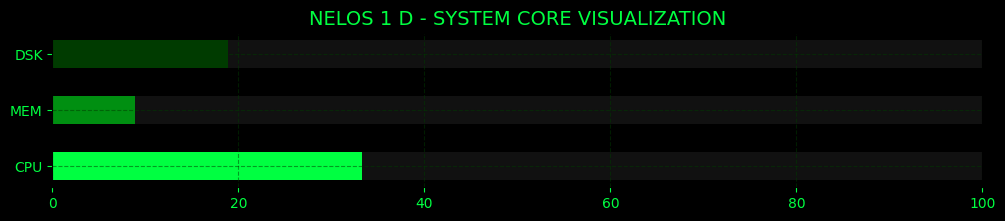

ACTIVE PROCESSES:
PID: 6744 | NAME: node                 | USAGE: 1.68%
PID: 6714 | NAME: python3              | USAGE: 1.35%
PID: 83 | NAME: jupyter-server       | USAGE: 1.19%
PID: 66 | NAME: colab-fileshim.      | USAGE: 0.58%
PID: 7 | NAME: node                 | USAGE: 0.44%

NETWORK UPLINK: 787.07 KB | DOWNLINK: 585.20 KB
STORAGE NODES:
MOUNT: /usr/sbin/docker-init [██████░░░░] 64.8%
MOUNT: /kaggle/input   [█░░░░░░░░░] 18.6%
MOUNT: /etc/resolv.conf [█░░░░░░░░░] 18.6%
MOUNT: /etc/hostname   [█░░░░░░░░░] 18.6%
MOUNT: /etc/hosts      [█░░░░░░░░░] 18.6%


In [ ]:
# Execute full system scan loop
try:
    for _ in range(5):
        state = get_system_state()
        ext_state = get_extended_state()
        visualize_extended_deck(state, ext_state)
        time.sleep(1)
except KeyboardInterrupt:
    print("Cyberdeck expansion offline.")